# Python pour la Data Science

## Notebook 05 - De la visualisation à l'analyse de données  

### De Matplotlib à Seaborn, puis transition vers un mini-projet d'analyse de ventes de chocolat

Dans cette séance, l'objectif est de voir la dernière bibliothèque prévue au syllabus du cours, mais pas que !

L'objectif est aussi de **faire le lien entre les outils vus jusqu'ici** et **un vrai début de projet de data science**

À la fin de ce notebook, nous pourrons :

1. produire des graphiques lisibles avec **Seaborn**
2. explorer un dataset de plusieurs fichiers avec des questions simples
3. comprendre pourquoi des données sont réparties dans **plusieurs tables**
4. utiliser `merge()` pour préparer une table d'analyse
5. commencer à répondre à des **question du métier de data analyst / scientist** à partir de ces données :

    - Quels produits se vendent le mieux ?
    - Quels clients dépensent le plus ?
    - Y a-t-il des tendances dans le temps ?
    - Comment une visualisation peut-elle aider à comprendre un phénomène ?

## Plan de la séance

1. **Reprendre Iris** sur Matplotlib puis **faire la transition** vers Seaborn (qui s'appuie sur Matplotlib comme Pandas s'appuie sur NumPy)
2. Voir **ce que Seaborn apporte** par rapport à Matplotlib  
3. Introduire le projet **Chocolate Sales** comme un cas plus réaliste  
4. Comprendre les **clés de jointure** et utiliser `merge()`  
5. Réaliser de premières analyses

# Mini-projet introductif - Analyse du dataset Iris

## Données

Chargez le dataset `Iris.csv`, puis explorez-le rapidement :

- Combien y a-t-il d’observations ?
- Combien y a-t-il de variables ?
- Quelles sont les espèces présentes ?

## Travail demandé

Vous devez produire une **analyse visuelle** permettant de répondre à la question :

*Comment distinguer les différentes espèces d’iris ?*

Réalisez **3 à 5 visualisations pertinentes**.

Vos visualisations doivent inclure :

- au moins **1 histogramme** (distribution d’une variable)
- au moins **1 comparaison entre espèces**
- au moins **1 graphique libre** (au choix)

## Pistes de réflexion

Vous pouvez vous poser les questions suivantes :

- Les pétales sont-ils plus discriminants que les sépales ?
- Une espèce est-elle clairement identifiable ?
- Certaines espèces se ressemblent-elles ?
- Quelles variables permettent le mieux de distinguer les espèces ?

## Pour chaque graphique

Vous devez fournir :

1. Le code utilisé
2. Le graphique obtenu
3. Une **interprétation (2-3 phrases)** expliquant ce que vous observez

## Bonus (optionnel)

- Représentez deux variables en même temps (scatter plot)
- Essayez de **colorier les points selon l’espèce**

---

L’objectif n’est pas seulement de faire des graphiques, mais de **raconter une histoire avec les données**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Chargement du fichier
df = pd.read_csv("../datasets/Iris.csv")

# Aperçu
print(df.head())

# Dimensions
print("Nombre d'observations :", df.shape[0])
print("Nombre de variables :", df.shape[1])

# Noms des colonnes
print("Colonnes :", df.columns.tolist())

# Espèces présentes
print("Espèces présentes :", df["Species"].unique())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Nombre d'observations : 150
Nombre de variables : 6
Colonnes : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Espèces présentes : ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


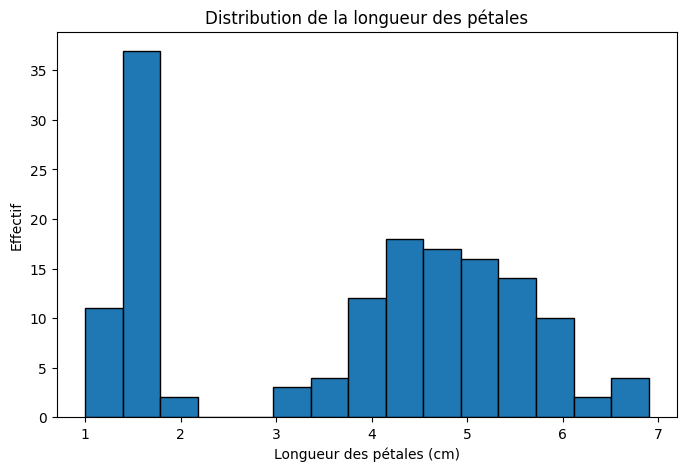

In [3]:
plt.figure(figsize=(8,5))
plt.hist(df["PetalLengthCm"], bins=15, edgecolor="black")
plt.title("Distribution de la longueur des pétales")
plt.xlabel("Longueur des pétales (cm)")
plt.ylabel("Effectif")
plt.show()

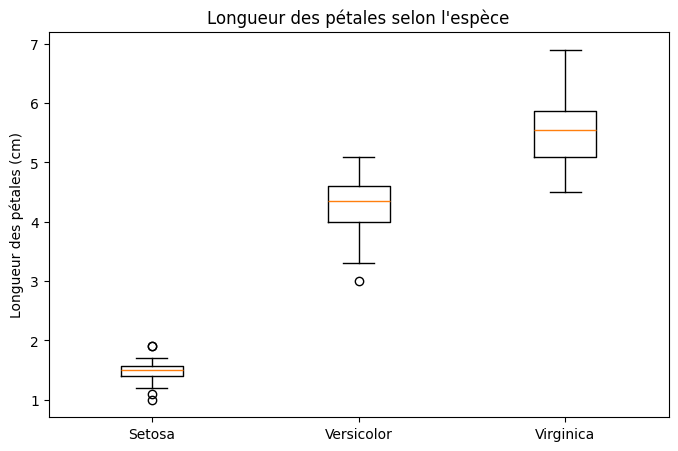

In [4]:
setosa = df[df["Species"] == "Iris-setosa"]["PetalLengthCm"]
versicolor = df[df["Species"] == "Iris-versicolor"]["PetalLengthCm"]
virginica = df[df["Species"] == "Iris-virginica"]["PetalLengthCm"]

plt.figure(figsize=(8,5))
plt.boxplot([setosa, versicolor, virginica],
            tick_labels=["Setosa", "Versicolor", "Virginica"])
plt.title("Longueur des pétales selon l'espèce")
plt.ylabel("Longueur des pétales (cm)")
plt.show()

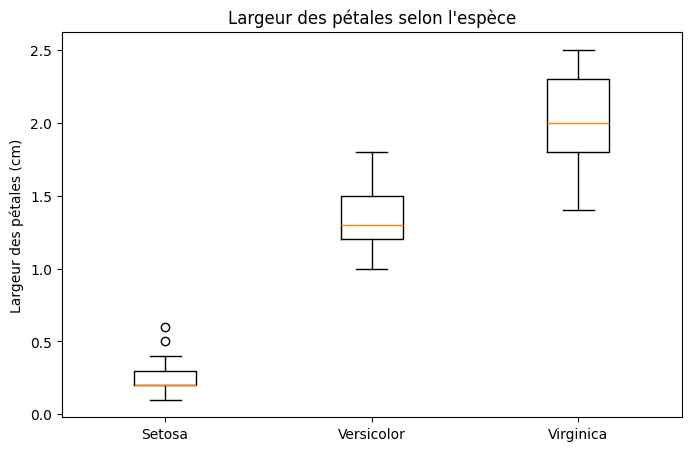

In [5]:
setosa = df[df["Species"] == "Iris-setosa"]["PetalWidthCm"]
versicolor = df[df["Species"] == "Iris-versicolor"]["PetalWidthCm"]
virginica = df[df["Species"] == "Iris-virginica"]["PetalWidthCm"]

plt.figure(figsize=(8,5))
plt.boxplot([setosa, versicolor, virginica],
            tick_labels=["Setosa", "Versicolor", "Virginica"])
plt.title("Largeur des pétales selon l'espèce")
plt.ylabel("Largeur des pétales (cm)")
plt.show()

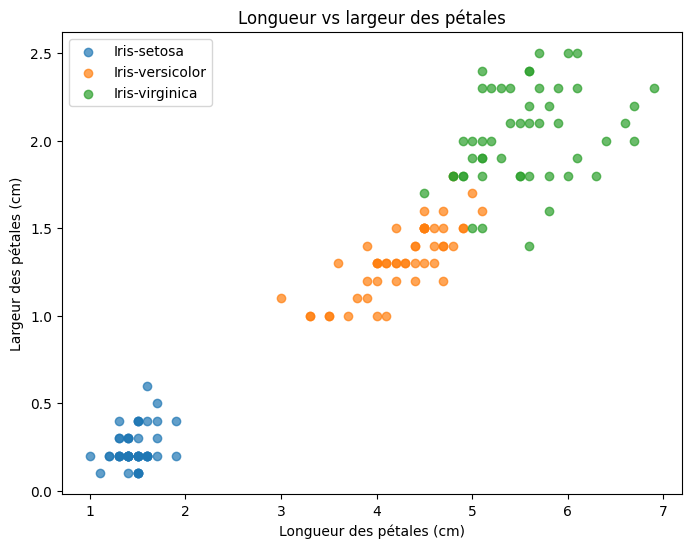

In [6]:
colors = {
    "Iris-setosa": "blue",
    "Iris-versicolor": "orange",
    "Iris-virginica": "green"
}

plt.figure(figsize=(8,6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(subset["PetalLengthCm"],
                subset["PetalWidthCm"],
                label=species,
                alpha=0.7)

plt.title("Longueur vs largeur des pétales")
plt.xlabel("Longueur des pétales (cm)")
plt.ylabel("Largeur des pétales (cm)")
plt.legend()
plt.show()

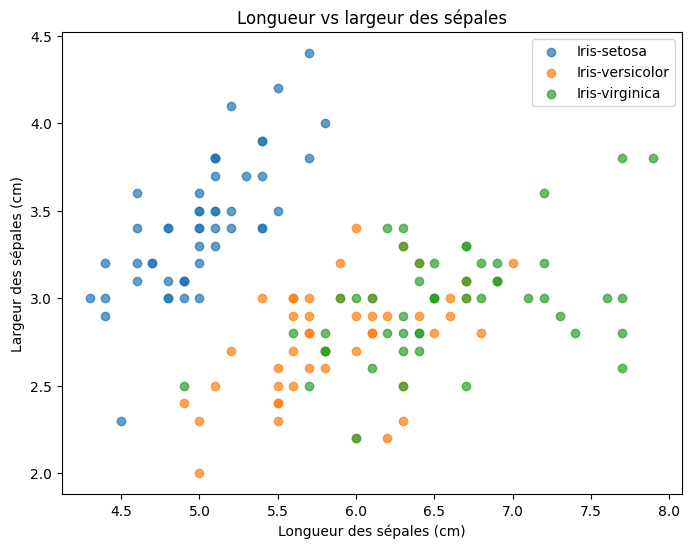

In [7]:
plt.figure(figsize=(8,6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(subset["SepalLengthCm"],
                subset["SepalWidthCm"],
                label=species,
                alpha=0.7)

plt.title("Longueur vs largeur des sépales")
plt.xlabel("Longueur des sépales (cm)")
plt.ylabel("Largeur des sépales (cm)")
plt.legend()
plt.show()

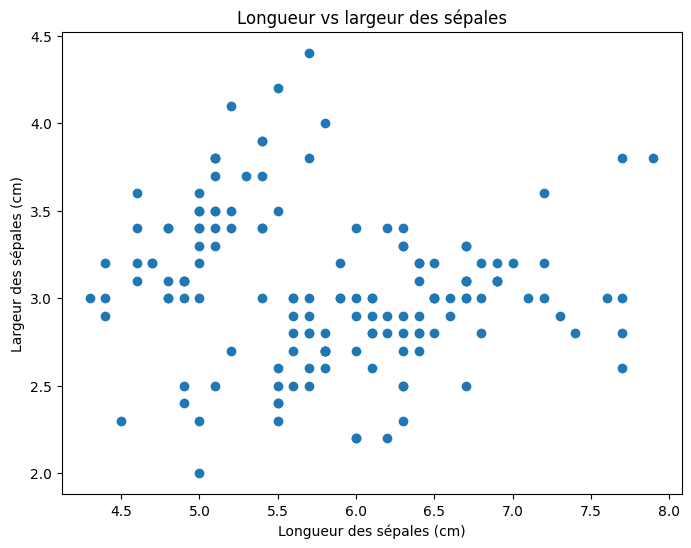

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df["SepalLengthCm"], df["SepalWidthCm"])
plt.title("Longueur vs largeur des sépales")
plt.xlabel("Longueur des sépales (cm)")
plt.ylabel("Largeur des sépales (cm)")
plt.show()

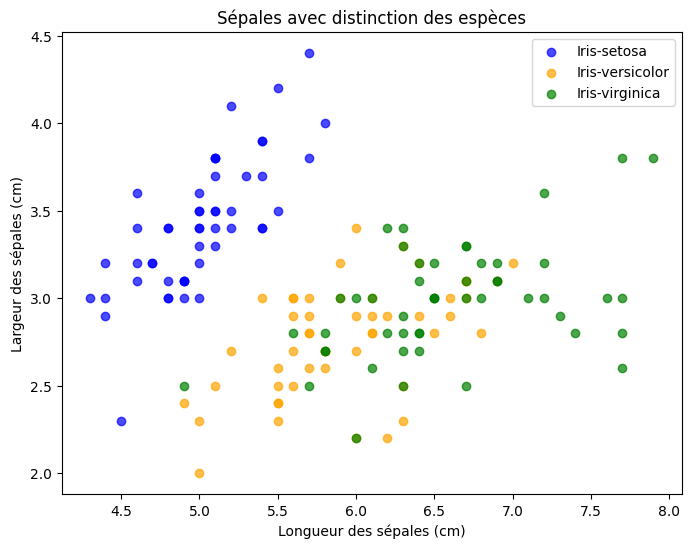

In [9]:
colors = {
    "Iris-setosa": "blue",
    "Iris-versicolor": "orange",
    "Iris-virginica": "green"
}

plt.figure(figsize=(8,6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(subset["SepalLengthCm"],
                subset["SepalWidthCm"],
                color=colors[species],
                label=species,
                alpha=0.7)

plt.title("Sépales avec distinction des espèces")
plt.xlabel("Longueur des sépales (cm)")
plt.ylabel("Largeur des sépales (cm)")
plt.legend()
plt.show()

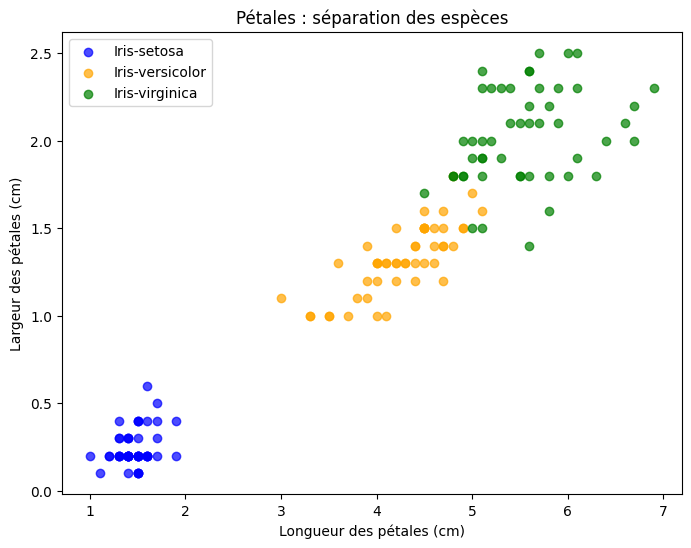

In [10]:
plt.figure(figsize=(8,6))

for species in df["Species"].unique():
    subset = df[df["Species"] == species]
    plt.scatter(subset["PetalLengthCm"],
                subset["PetalWidthCm"],
                color=colors[species],
                label=species,
                alpha=0.7)

plt.title("Pétales : séparation des espèces")
plt.xlabel("Longueur des pétales (cm)")
plt.ylabel("Largeur des pétales (cm)")
plt.legend()
plt.show()

## 1. Pourquoi Seaborn ?

Vous avez déjà vu **NumPy**, **Pandas** et **Matplotlib**.

Matplotlib reste très important :
- il permet de comprendre la logique de construction d'un graphique
- il offre beaucoup de contrôle
- il est très utilisé

Mais en exploration de données, on veut souvent :
- aller plus vite
- obtenir un graphique propre avec moins de code que via Matlplotlib
- relier directement un graphique à un DataFrame Pandas
- colorer, comparer et résumer automatiquement les graphes pour produire nos analyses

C'est exactement ce que propose **Seaborn**

### Initialisation de la bibliothèque Seaborn

Souvent, on donne le nom `sns` à la bibliothèque Seaborn

Pour débuter un projet de Data Science avec Seaborn et Pandas (surtout), on peut initialiser deux choses : `set_theme` dans Seaborn configure le style graphique global, ici on va lui donner un fond blanc avec une grille légère (pour la visibilité), `set_option` dans Pandas permet de demander d'afficher un nombre maximal de colonnes (les datasets peuvent avoir un très grand nombre de colonnes) : on va ici le paramétrer à 50

In [11]:
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Reprendre le dataset Iris

Nous repartons d'un dataset déjà connu `Iris.csv` :

On charge le dataset Iris et on se re-familiarise avec les données présentes : premières lignes, forme du DataFrame, noms des colonnes, espèces uniques présentes...

In [12]:
iris = pd.read_csv("../datasets/Iris.csv")
iris.head()

print("Dimensions :", iris.shape)
print("Colonnes :", iris.columns.tolist())
print("Espèces présentes :", iris["Species"].unique())

Dimensions : (150, 6)
Colonnes : ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Espèces présentes : ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


## 3. Premier exemple : distribution d'une variable

Nous voulons observer la distribution de `SepalLengthCm`

On le fait d'abord en **version Matplotlib** :

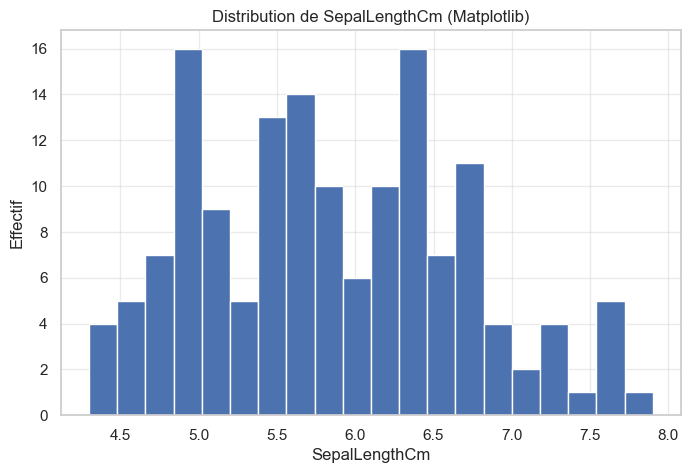

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(iris["SepalLengthCm"], bins=20)

plt.title("Distribution de SepalLengthCm (Matplotlib)")
plt.xlabel("SepalLengthCm")
plt.ylabel("Effectif")
plt.grid(True, alpha=0.4)

plt.show()

Puis, **en version Seaborn** : quelles différences voyons-nous ?

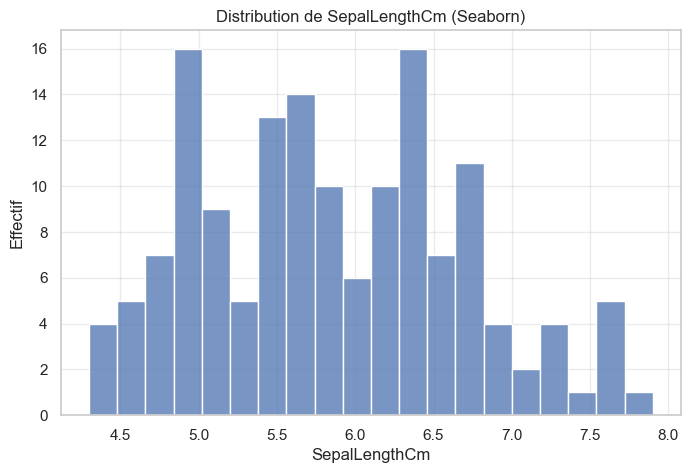

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(data=iris, x="SepalLengthCm", bins=20)

plt.title("Distribution de SepalLengthCm (Seaborn)")
plt.xlabel("SepalLengthCm")
plt.ylabel("Effectif")
plt.grid(True, alpha=0.4)

plt.show()

Avec Seaborn :

- on indique directement `data=iris`
- on référence les colonnes par leur nom

On commence à voir que Seaborn est très pratique pour **explorer rapidement un DataFrame** mais ce n'est pas tout :

- certaines options de seaborn sont très pratiques, par exemple pour obtenir une courbe de densité au-dessus de l'histogramme :

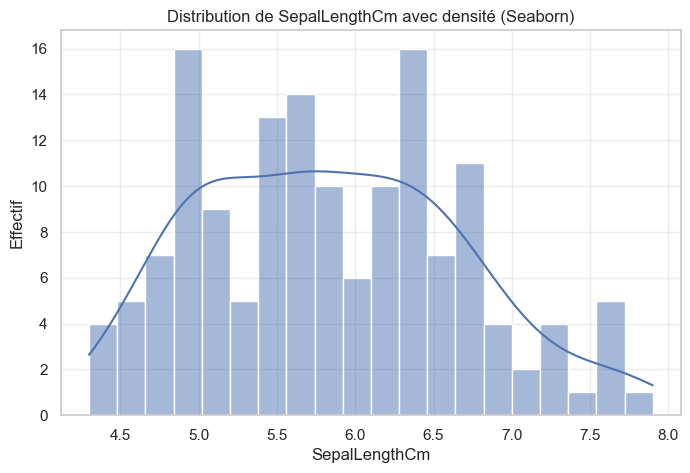

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=iris, x="SepalLengthCm", bins=20, kde=True)

plt.title("Distribution de SepalLengthCm avec densité (Seaborn)")
plt.xlabel("SepalLengthCm")
plt.ylabel("Effectif")
plt.grid(True, alpha=0.4)

plt.show()

Si je fais pareil avec Matplotlib, je vais obtenir...

L'argument `kde` n'existe pas pour Matplotlib : on pourrait quand même obtenir le même graphe, mais il faudrait écrire plus de lignes de code et utiliser NumPy pour calculer "à la main" la densité et en afficher la courbe !

### Exercice 1 - Graphe de distribution

Reproduisez un graphique de distribution en changeant :

- soit la variable, par exemple `PetalLengthCm`
- soit le type de représentation, par exemple avec `kdeplot`

**Interprétation du graphe**

1. Quelle variable semble la plus étalée ?
2. Avez-vous l'impression qu'il y a une ou plusieurs zones de concentration ?

## 4. Comparer des groupes

Un besoin très fréquent en data science est de **comparer des sous-groupes** : ici, nous allons comparer les espèces d'iris à l'aide de deux représentations : `boxplot` que nous avons déjà vue avec Matplotlib, et `violinplot`

- Un `violinplot` montre la distribution complète des données en combinant l’étendue et la densité (largeur = concentration des valeurs), tandis qu’un `boxplot` résume uniquement les statistiques principales (médiane, quartiles, extrêmes) sans montrer la forme détaillée de la distribution

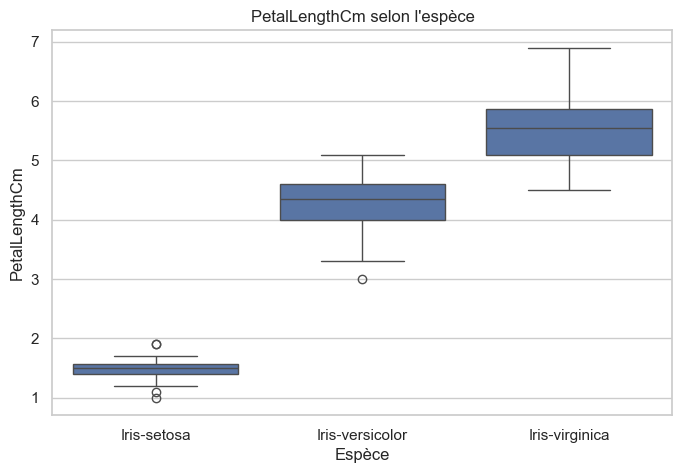

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=iris, x="Species", y="PetalLengthCm")
plt.title("PetalLengthCm selon l'espèce")
plt.xlabel("Espèce")
plt.ylabel("PetalLengthCm")

plt.show()

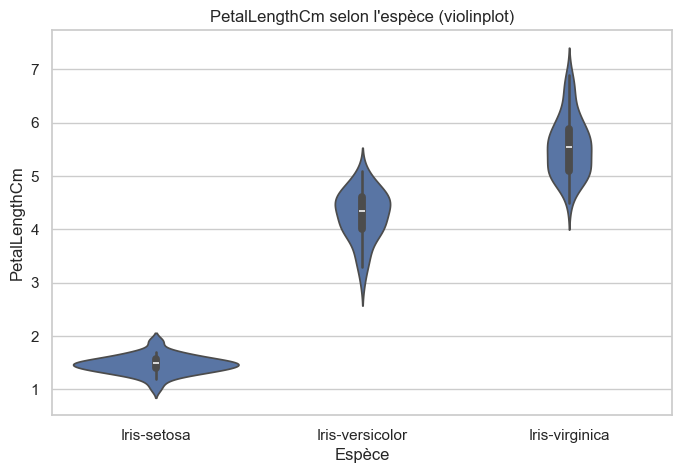

In [17]:
plt.figure(figsize=(8, 5))

sns.violinplot(data=iris, x="Species", y="PetalLengthCm")

plt.title("PetalLengthCm selon l'espèce (violinplot)")
plt.xlabel("Espèce")
plt.ylabel("PetalLengthCm")

plt.show()

Ces graphiques permettent de voir rapidement :

- si les (sous-)groupes (ici les espèces d'Iris) ont des niveaux différents sur une variable d'intérêt
- si un groupe est plus dispersé qu'un autre
- si certaines distributions semblent plus homogènes

En pratique, ce type de graphique est très utile pour comparer des catégories : produits, régions, types de clients, ...

### Exercice 2 - Boxplot et Violinplot

1. Comparez les espèces selon `SepalWidthCm` avec un **boxplot**
2. Faites ensuite un **violinplot**
3. Essayez sur d'autres variables (peut-être avec des subplots ?)

**Interprétation**

- Quelle espèce paraît la plus homogène ?
- Quelle variable semble mieux séparer les espèces ?

## 5. Étudier la relation entre deux variables

Autre situation très classique : chercher une relation entre deux variables numériques. On va pour ça utiliser le paramètre `hue=` qui est très puissant :

- il colore automatiquement les observations selon une variable catégorielle (ici on va prendre la variable `Species`)
- il permet de repérer rapidement des groupes
- il rend les relations beaucoup plus lisibles

**C'est l'un des grands intérêts de Seaborn dans une analyse exploratoire de données**

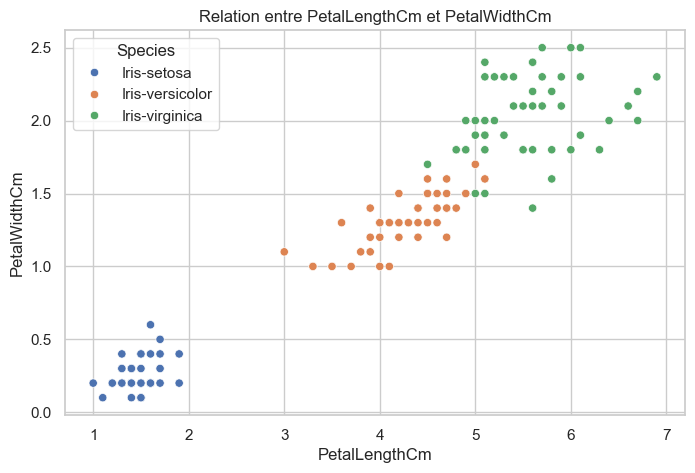

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=iris, x="PetalLengthCm", y="PetalWidthCm", hue="Species")

plt.title("Relation entre PetalLengthCm et PetalWidthCm")
plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")

plt.show()

Que remarque-t-on ?

### Exercice 3 - Scatterplot avec hue

Créez un `scatterplot` entre :

- `SepalLengthCm`
- `SepalWidthCm`

Puis ajoutez `hue="Species"`

**Interprétation**

- Voyez-vous une relation nette ?
- Les espèces sont-elles bien séparées ?
- Cette visualisation est-elle plus ou moins informative que celle sur les pétales ?

## 6. Vue d'ensemble avec `pairplot`

Quand on veut une première exploration rapide de plusieurs variables numériques, Seaborn fournit `pairplot`

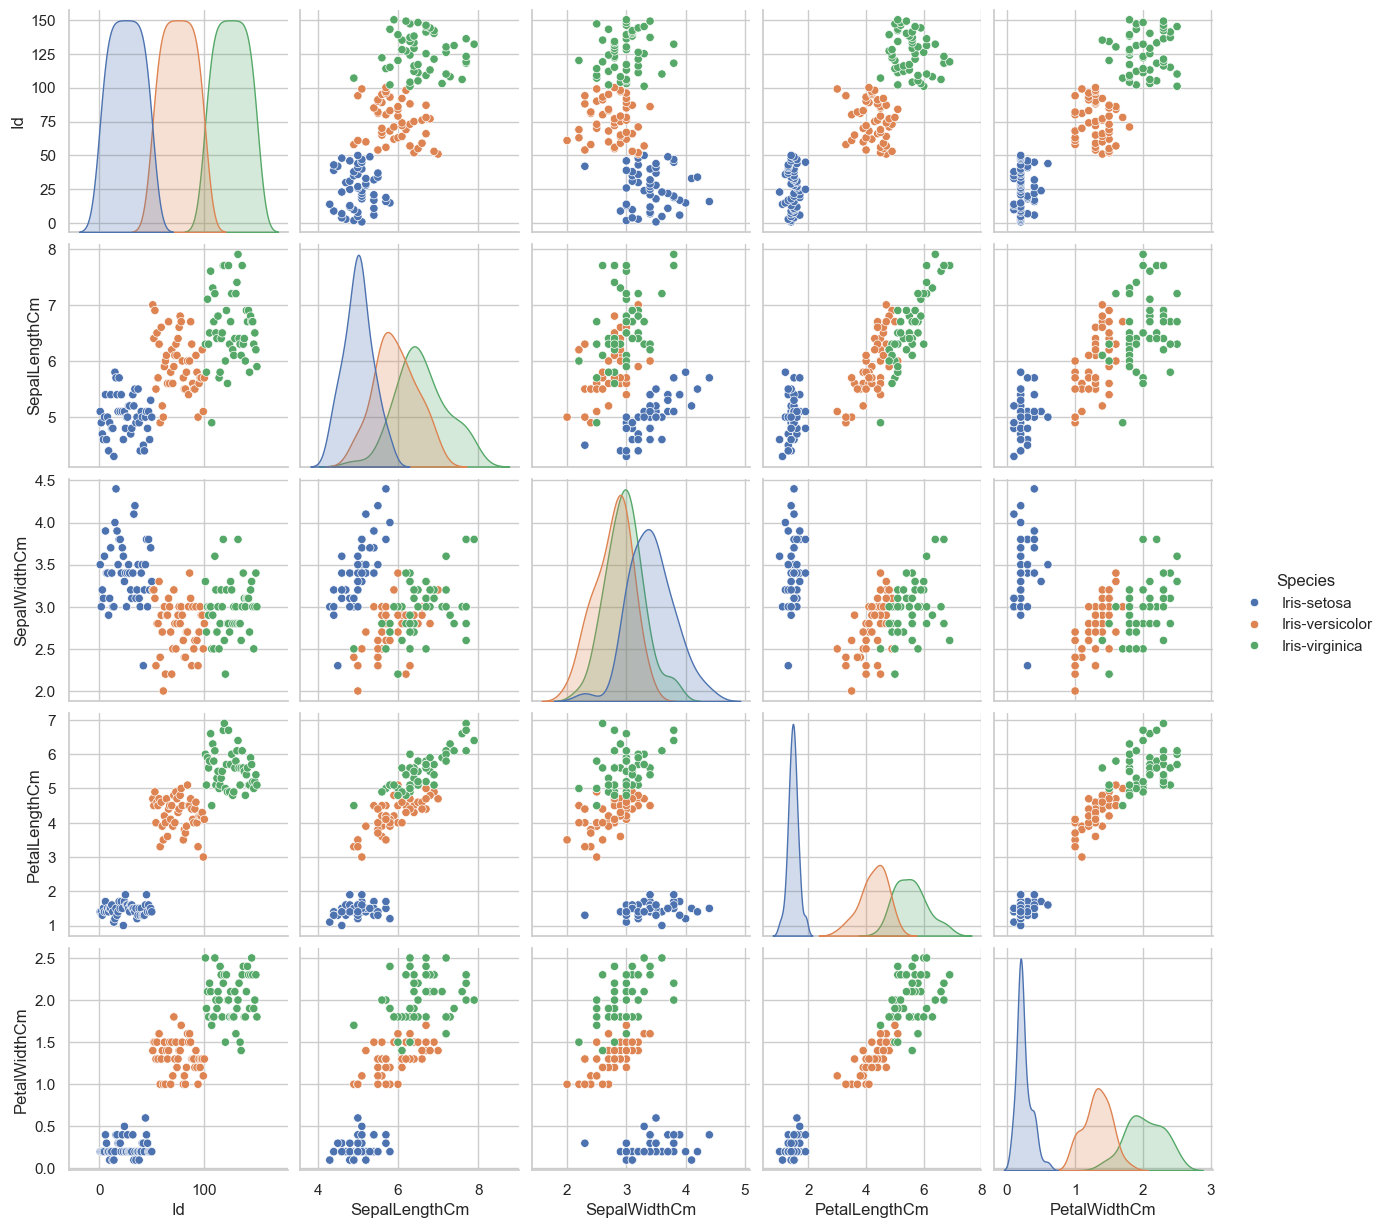

In [19]:
sns.pairplot(iris, hue="Species")

plt.show()

Qu'observe-t-on ? **Commentez ces graphes**

On a beaucoup de graphes à afficher, et certains semblent inutiles : notamment, ceux qui correspondent à la colonnel `Id` ne donnent pas plus d'informations que les courbes de densités en diagonale. On peut donc dire à Seaborn de ne pas prendre en compte la colonne `Id` du DataFrame en utilisant l'argument `drop`

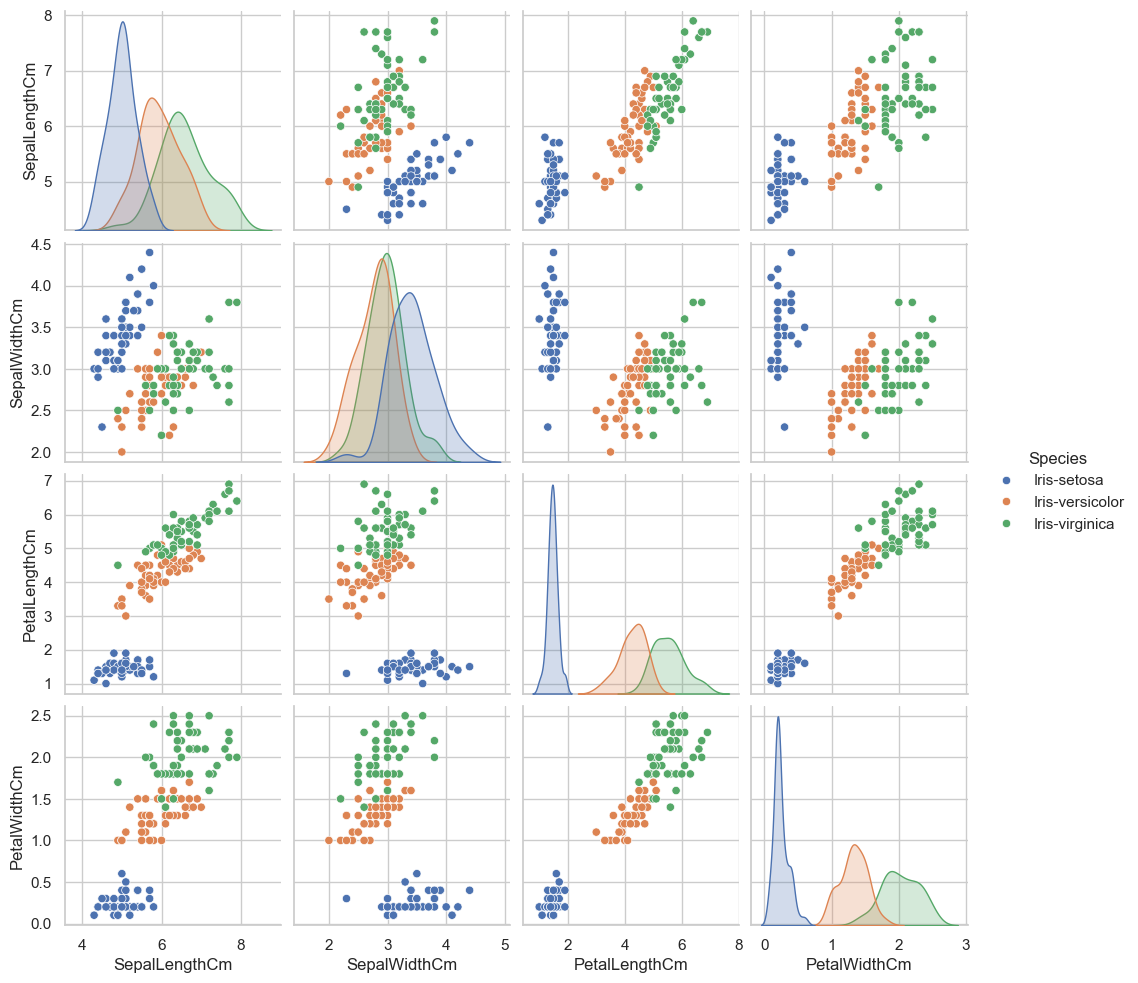

In [20]:
sns.pairplot(iris.drop(columns="Id"), hue="Species")

plt.show()

### Bilan intermédiaire

Jusqu'ici, nous avons utilisé Seaborn pour :

- visualiser une **distribution**
- comparer des **groupes**
- repérer des **relations** entre variables

**C'est ce qu'on commence généralement par faire dans un projet de data analyse/science**

On ne commence pas par un modèle compliqué, on commence souvent par :

1. comprendre les colonnes (comme ce qu'on faisait avec Pandas)
2. visualiser les variables
3. repérer des différences, tendances ou anomalies
4. formuler des premières hypothèses

# 7. Transition vers un vrai jeu de données

Le dataset `Iris` est très utile pour apprendre, mais il reste petit et simple, peu ressemblant à ce qu'on peut rencontrer dans la vraie vie (ou le monde professionnel)

Dans un projet plus réaliste, les données sont souvent :

- réparties dans **plusieurs fichiers**
- liées entre elles par des identifiants
- proches d'un contexte métier
- moins immédiates à lire

Nous allons maintenant travailler sur un dataset de **ventes de chocolat** en essayant de voir si on peut apporter des réponses au type de questions suivant :

> Que peut-on apprendre sur les ventes et la performance commerciale à partir des données ?

Concrètement, nous allons essayer de voir concrètement ce que peuvent apporter les méthodes de data science pour :

- transformer des fichiers bruts en information exploitable
- répondre à une question métier avec des graphiques
- justifier une idée à partir de données
- relier technique et interprétation

Nous n'allons pas seulement afficher des graphes, mais **nous servir des données pour comprendre une situation**

## 8. Charger les fichiers du projet

Nous allons utiliser plusieurs tables :

- `sales` : les ventes
- `products` : les produits
- `stores` : les magasins
- `customers` : les clients
- `calendar` : des informations sur les dates

Chargeons les fichiers comme on a l'habitude de le faire :

In [21]:
sales = pd.read_csv("../datasets/ventes chocolat/sales.csv")

products = pd.read_csv("../datasets/ventes chocolat/products.csv")

stores = pd.read_csv("../datasets/ventes chocolat/stores.csv")

customers = pd.read_csv("../datasets/ventes chocolat/customers.csv")

calendar = pd.read_csv("../datasets/ventes chocolat/calendar.csv")

Pour plus de praticité, on peut mettre nos différents datasets dans un **dictionnaire** pour en afficher les informations de base plus rapidement (d'où l'utilité de savoir comment manipuler les structures de données simples) :

In [22]:
datasets = {
    "sales": sales,
    "products": products,
    "stores": stores,
    "customers": customers,
    "calendar": calendar,
}

for name, df in datasets.items():
    print(f"\n{name.upper()} : {df.shape[0]} lignes, {df.shape[1]} colonnes")
    display(df.head())


SALES : 1000000 lignes, 11 colonnes


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40



PRODUCTS : 200 lignes, 6 colonnes


,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50



STORES : 100 lignes, 5 colonnes


,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online



CUSTOMERS : 50000 lignes, 5 colonnes


,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31



CALENDAR : 731 lignes, 6 colonnes


,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


### Exercice 4 - Découverte des datasets

Prenez quelques minutes pour explorer les tables :

- regardez les premières lignes
- identifiez les colonnes
- essayez de deviner le rôle de chaque table

**Interprétation** :

1. Quelle table semble être la table principale ?
2. Quelles colonnes paraissent être des identifiants ?
3. Quelles informations semblent descriptives ?

In [23]:
for name, df in datasets.items():
    print(f"\n{name.upper()} :")
    print(df.columns.tolist())


SALES :
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']

PRODUCTS :
['product_id', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g']

STORES :
['store_id', 'store_name', 'city', 'country', 'store_type']

CUSTOMERS :
['customer_id', 'age', 'gender', 'loyalty_member', 'join_date']

CALENDAR :
['date', 'year', 'month', 'day', 'week', 'day_of_week']


## Lecture métier du dataset

On peut déjà faire une première interprétation :

- `sales` contient les **événements de vente** : c'est la table principale
- `products` décrit les produits
- `stores` décrit les magasins
- `customers` décrit les clients
- `calendar` ajoute du contexte temporel

Autrement dit :

- `sales` décrit **ce qui s'est passé**
- les autres tables décrivent **le contexte** de chaque vente.

C'est une organisation très fréquente de ce type de données

# 9. Comprendre les clés de jointure et `merge()`

**C'est une étape essentielle** : dans un projet réel, les données ne sont presque jamais réunies dans un seul tableau

Il faut donc savoir **relier plusieurs tables**

## 9.1 Pourquoi plusieurs tables ?

On pourrait imaginer une seule énorme table contenant :
- la vente ;
- le nom du produit ;
- la marque ;
- le magasin ;
- le pays ;
- l'âge du client ;
- etc.

Mais cela poserait un problème : **les mêmes informations seraient répétées encore et encore** (les données ne seraient pas vraiment propres pour une bonne analyse)

Par exemple, si un produit apparaît dans des milliers de ventes, son nom serait répété des milliers de fois

Séparer les données en plusieurs tables permet donc :

- d'éviter les répétitions inutiles
- de mieux organiser l'information
- de limiter les incohérences
- de rendre les mises à jour plus simples

## 9.2 Qu'est-ce qu'une clé ?

Pour relier deux tables, on utilise une **clé**

Une clé est une colonne qui sert d'identifiant commun entre deux tables

**Quelles sont les clés que nous pouvons utiliser ?**

Dans notre dataset :

- `product_id` relie `sales` et `products`
- `store_id` relie `sales` et `stores`
- `customer_id` relie `sales` et `customers`
- `order_date` peut être reliée à `date` dans `calendar`

Une clé permet de dire "cette vente correspond à ce produit, à ce magasin, à ce client et à cette date"

## 9.3 Exemple simple de `merge()`

Quand la colonne a le même nom dans les deux tables, on utilise :

```python
nouvelle_table = table1.merge(table2, on="colonne_commune")
```

Une fois les tables merged, on peut essayer de voir quelles colonnes contient la nouvelle table que l'on vient de créer

In [24]:
sales_products = sales.merge(products, on="product_id")
sales_products.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70,200
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60,50
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90,50
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60,50
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90,120


In [25]:
print("Colonnes avant merge :")
print(sales.columns.tolist())

print("\nColonnes après merge entre sales et products :")
print(sales_products.columns.tolist())

Colonnes avant merge :
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit']

Colonnes après merge entre sales et products :
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g']


On s'aperçoit bien que les colonnes de notre nouvelle table comprennent la table `sales` à laquelle on vient de rajouter les colonnes de la table `products` à partir de la colonne `product_id` qui était commune aux deux tables : j'accède donc à mes données de ventes en y rajoutant, pour chaque vente, les caractéristiques du produit vendu !

## 9.4 Quand les noms de colonnes diffèrent

Je veux faire pareil avec la table résumant la date des commandes : que va donner le code suivant lorsque je vais l'exécuter ?

Ici, les noms des colonnes diffèrent !

- dans `sales`, la date de commande s'appelle `order_date`
- dans `calendar`, la date s'appelle `date`

Dans ce cas, on utilise :

- `left_on=` pour la colonne de la table de gauche
- `right_on=` pour la colonne de la table de droite

In [26]:
sales_calendar = sales.merge(calendar, left_on="order_date", right_on="date")
sales_calendar.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,2024-09-24,2024,9,24,39,1


### Exercice 5 - Jointures

Faisons des jointures simples :

- entre `sales` et `stores`
- entre `sales` et `customers`

**Interprétation** :

- Quelle nouvelle information apparaît après la jointure ?
- À quoi peut-elle servir dans une future analyse ?

# 10. Construire progressivement la table d'analyse

À partir du principe de jointure, nous allons construire une table finale plus riche pour l'analyse.

L'idée est de :

1. partir de `sales`
2. y ajouter les produits
3. y ajouter les magasins
4. y ajouter les clients
5. y ajouter le calendrier

### Exercice 6 - Création de la table d'analyse

Écrire la construction de la table finale à partir de ces indices :

- commencez par `sales.merge(products, on="product_id")`
- poursuivez étape par étape
- terminez avec la jointure sur la date

Puis vérifiez :

- le nombre de lignes
- le nombre de colonnes
- quelques lignes du résultat final

In [27]:
df = (
    sales
    .merge(products, on="product_id")
    .merge(stores, on="store_id")
    .merge(customers, on="customer_id")
    .merge(calendar, left_on="order_date", right_on="date")
)

print(f"Table finale : {df.shape[0]} lignes, {df.shape[1]} colonnes")

df.head()

Table finale : 990236 lignes, 30 colonnes


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type,age,gender,loyalty_member,join_date,date,year,month,day,week,day_of_week
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56,Praline Chocolate 70%,Hershey,White,70,200,Chocolate Store 93,Sydney,UK,Airport,44,Male,1,2021-11-17,2023-01-07,2023,1,7,1,5
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97,Dark Chocolate 60%,Lindt,Praline,60,50,Chocolate Store 65,New York,Australia,Retail,63,Female,1,2023-07-03,2023-10-22,2023,10,22,42,6
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75,Milk Chocolate 90%,Hershey,Milk,90,50,Chocolate Store 78,London,UK,Airport,35,Male,1,2023-10-09,2023-05-07,2023,5,7,18,6
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04,Dark Chocolate 60%,Godiva,Praline,60,50,Chocolate Store 88,Toronto,USA,Retail,37,Female,1,2023-05-30,2024-06-23,2024,6,23,25,6
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40,Truffle Chocolate 90%,Hershey,Truffle,90,120,Chocolate Store 54,London,Canada,Online,57,Female,0,2021-08-20,2024-09-24,2024,9,24,39,1


## Pourquoi cette étape est-elle importante ?

Dans la vraie vie, une grande partie du travail en data science consiste à :

- **préparer les données** 
- les rendre exploitables
- rassembler des sources séparées
- construire une table d'analyse cohérente

**D'où l'intérêt de savoir faire une jointure !**

# 11. Premières analyses guidées

Nous allons maintenant utiliser cette table finale pour répondre à quelques questions simples (sans volonté d'exhaustivité) :

L'objectif est de voir comment :

- poser une question
- préparer un regroupement avec Pandas
- produire une visualisation
- interpréter le résultat

## 11.1 Quels produits génèrent le plus de chiffre d'affaires ?


In [28]:
df.columns.tolist()

['order_id',
 'order_date',
 'product_id',
 'store_id',
 'customer_id',
 'quantity',
 'unit_price',
 'discount',
 'revenue',
 'cost',
 'profit',
 'product_name',
 'brand',
 'category',
 'cocoa_percent',
 'weight_g',
 'store_name',
 'city',
 'country',
 'store_type',
 'age',
 'gender',
 'loyalty_member',
 'join_date',
 'date',
 'year',
 'month',
 'day',
 'week',
 'day_of_week']

### Exercice 7 - Manipulation des données autour des produits et du chiffre d'affaires

1. Identifiez la colonne du produit
2. Identifiez la colonne correspondant au montant ou au chiffre d'affaires
3. Faites un `groupby`
4. Triez les résultats
5. Affichez un graphique avec Seaborn

**Interprétation**  
Si vous étiez responsable produit, que feriez-vous à partir de ce résultat ?

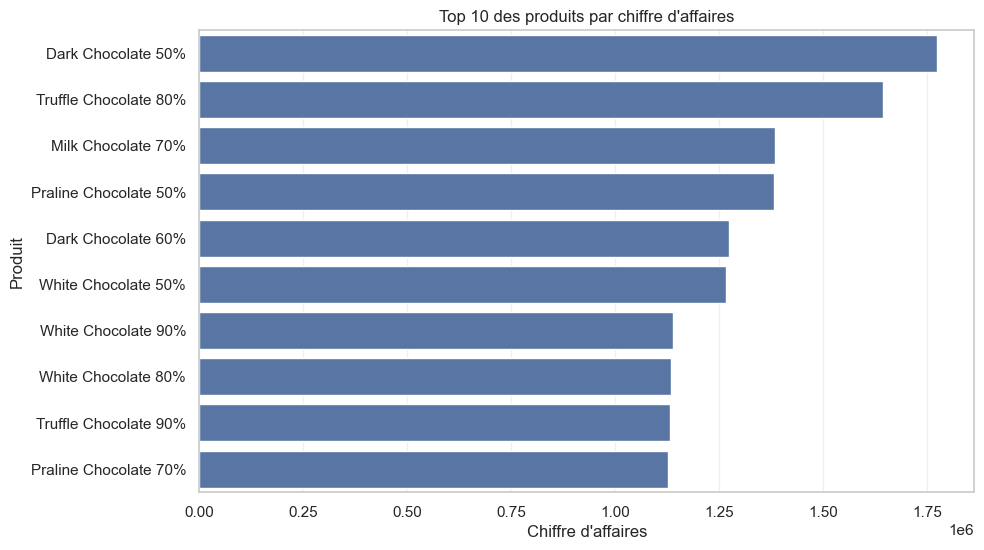

In [29]:
ca_par_produit = (
    df.groupby("product_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=ca_par_produit, x="revenue", y="product_name")

plt.title("Top 10 des produits par chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Produit")
plt.grid(True, axis="x", alpha=0.3)

plt.show()

## 11.2 Quels clients dépensent le plus ?


### Exercice 8 - Qui est le plus gros client ?

1. Regroupez les données par client
2. Calculez le montant total dépensé
3. Visualisez les clients les plus importants

**Interprétation** :

Ces clients doivent-ils être ciblés différemment ?
Peut-on imaginer des actions de fidélisation ?

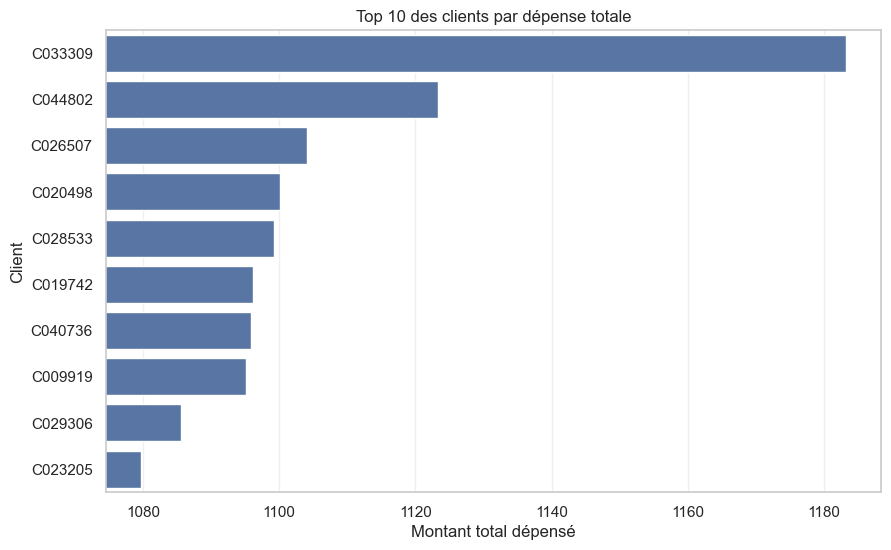

In [30]:
depense_par_client = (
    df.groupby("customer_id", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=depense_par_client, x="revenue", y="customer_id")

plt.title("Top 10 des clients par dépense totale")
plt.xlabel("Montant total dépensé")
plt.ylabel("Client")

xmin = depense_par_client["revenue"].min()
xmax = depense_par_client["revenue"].max()

marge = (xmax - xmin) * 0.05

plt.xlim(xmin - marge, xmax + marge)

plt.grid(True, axis="x", alpha=0.3)

plt.show()

## 11.3 Y a-t-il une évolution des ventes dans le temps ?

Pour répondre à cette question, on peut :
- convertir la date si nécessaire ;
- regrouper les ventes par date, semaine ou mois ;
- tracer une courbe.


### Exercice 9 - Évolution des ventes dans le temps

Essayez de produire une première courbe d'évolution dans le temps.

**Interprétation** :

- Voyez-vous une tendance générale ?
- Y a-t-il des pics ou des creux ?
- Cette information pourrait-elle être utile à un responsable commercial ?

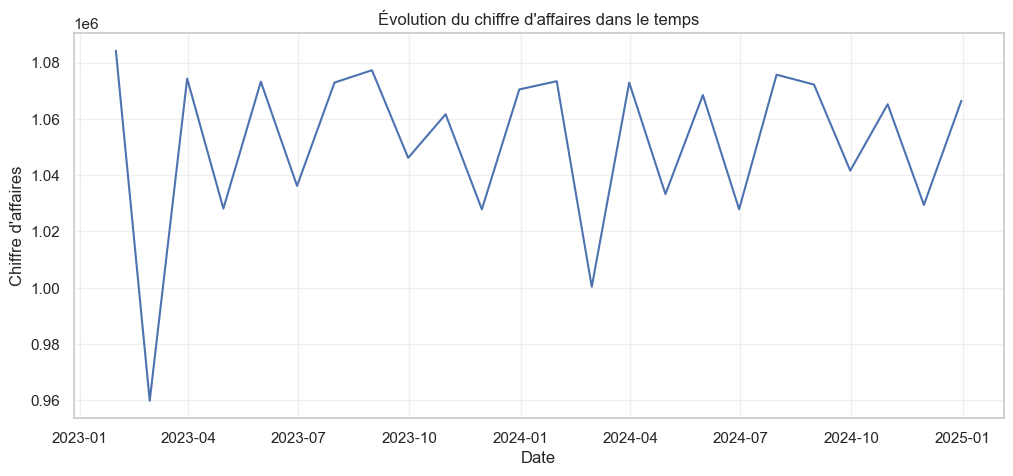

In [31]:
df["order_date"] = pd.to_datetime(df["order_date"])

ventes_par_mois = (
    df.groupby(pd.Grouper(key="order_date", freq="ME"))["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=ventes_par_mois, x="order_date", y="revenue")

plt.title("Évolution du chiffre d'affaires dans le temps")
plt.xlabel("Date")
plt.ylabel("Chiffre d'affaires")
plt.grid(True, alpha=0.3)

plt.show()

# 12. Mini-projet guidé

En autonomie, choisissez **une** question parmi les suivantes et répondez-y :

1. Quels produits sont les plus populaires ?
2. Les clients fidèles dépensent-ils davantage ?
3. Y a-t-il une tendance des ventes dans le temps ?
4. Les ventes varient-elles selon les magasins ?

**Objectif attendu**

- un petit traitement avec Pandas
- un graphique Seaborn
- 3 à 5 lignes d'interprétation

## Conseils

Pour réussir :
1. partez d'une question simple ;
2. identifiez les colonnes utiles ;
3. faites un `groupby` si nécessaire ;
4. utilisez une visualisation lisible ;
5. écrivez une interprétation en langage clair.

👉 Le plus important n'est pas de faire quelque chose de compliqué.  
Le plus important est de **relier une question, un traitement, un graphique et une interprétation**.


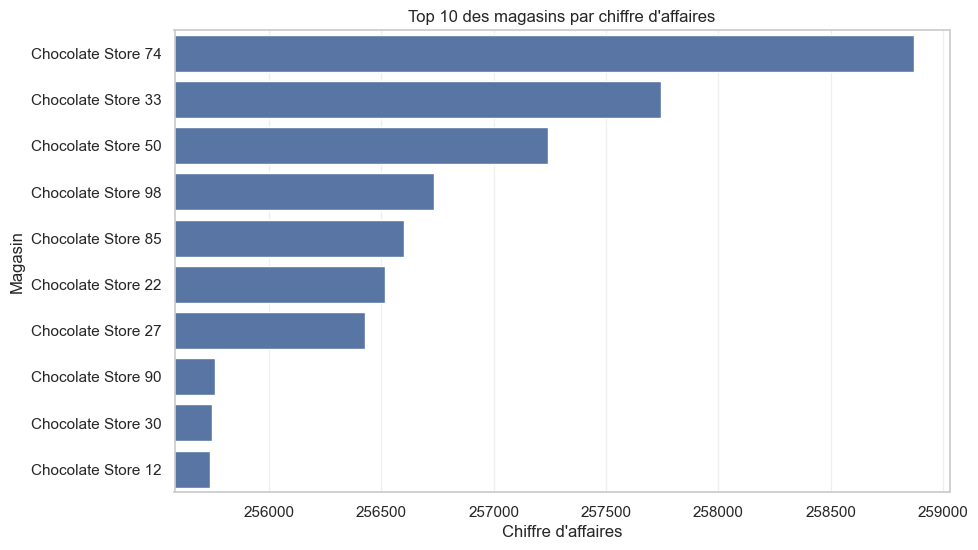

             revenue
count      10.000000
mean   256738.062000
std       995.593605
min    255736.300000
25%    255926.847500
50%    256559.260000
75%    257114.455000
max    258871.570000
Interprétation :
- Certains magasins génèrent nettement plus de chiffre d'affaires que d'autres.
- Cela peut refléter l'emplacement, la taille du magasin ou le type de clientèle.
- Ce résultat peut aider à identifier les magasins les plus performants et à comprendre leurs bonnes pratiques.


In [32]:
ventes_par_magasin = (
    df.groupby("store_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=ventes_par_magasin, x="revenue", y="store_name")

plt.title("Top 10 des magasins par chiffre d'affaires")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Magasin")
plt.grid(True, axis="x", alpha=0.3)

xmin = ventes_par_magasin["revenue"].min()
xmax = ventes_par_magasin["revenue"].max()

marge = (xmax - xmin) * 0.05

plt.xlim(xmin - marge, xmax + marge)

plt.show()

print(ventes_par_magasin.describe())

print("Interprétation :")
print("- Certains magasins génèrent nettement plus de chiffre d'affaires que d'autres.")
print("- Cela peut refléter l'emplacement, la taille du magasin ou le type de clientèle.")
print("- Ce résultat peut aider à identifier les magasins les plus performants et à comprendre leurs bonnes pratiques.")

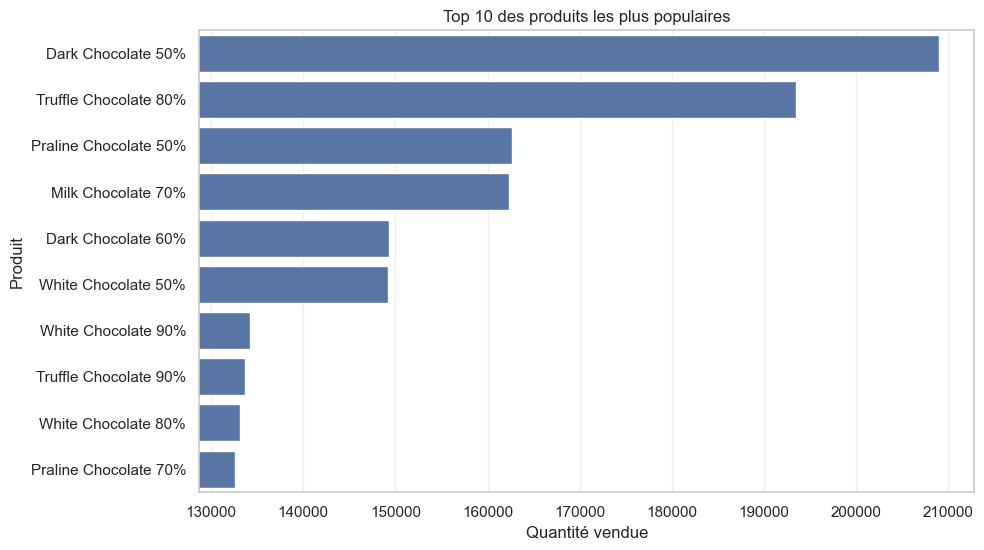

            quantity
count      10.000000
mean   155959.200000
std     26724.396182
min    132564.000000
25%    133823.250000
50%    149258.000000
75%    162586.250000
max    208996.000000
Interprétation :
- Certains produits dominent largement en termes de quantité vendue.
- Cela indique des préférences fortes des clients pour certains articles.
- Ces produits pourraient être mis en avant dans les stratégies marketing.
- À l’inverse, les produits moins vendus pourraient nécessiter une analyse ou une promotion.


In [33]:
top_products = (
    df.groupby("product_name", as_index=False)["quantity"]
    .sum()
    .sort_values("quantity", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x="quantity", y="product_name")

plt.title("Top 10 des produits les plus populaires")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.grid(True, axis="x", alpha=0.3)

xmin = top_products["quantity"].min()
xmax = top_products["quantity"].max()

marge = (xmax - xmin) * 0.05

plt.xlim(xmin - marge, xmax + marge)

plt.show()

print(top_products.describe())

print("Interprétation :")
print("- Certains produits dominent largement en termes de quantité vendue.")
print("- Cela indique des préférences fortes des clients pour certains articles.")
print("- Ces produits pourraient être mis en avant dans les stratégies marketing.")
print("- À l’inverse, les produits moins vendus pourraient nécessiter une analyse ou une promotion.")

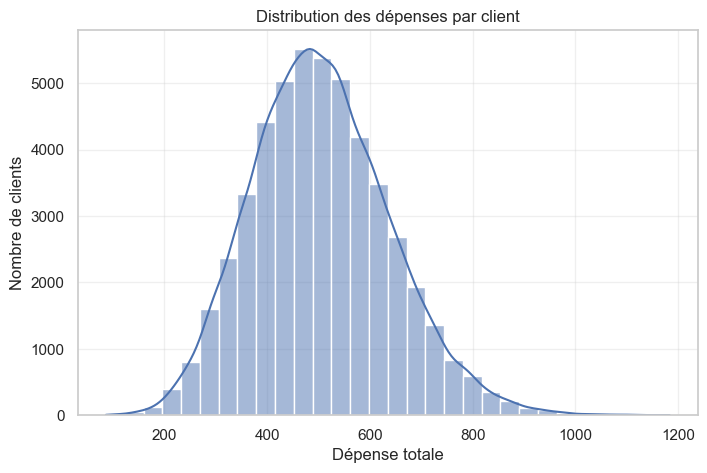

count    50000.000000
mean       504.772964
std        134.024584
min         86.340000
25%        410.797500
50%        497.520000
75%        590.825000
max       1183.160000
Name: revenue, dtype: float64
Interprétation :
- Une majorité de clients dépense relativement peu, tandis qu’un petit groupe dépense beaucoup.
- Cela suggère que les clients fidèles ou réguliers génèrent une part importante du chiffre d’affaires.
- Le comportement est donc inégal, avec quelques clients très rentables.
- Fidéliser ces clients est stratégique pour l’entreprise.


In [34]:
depense_client = df.groupby("customer_id")["revenue"].sum()

plt.figure(figsize=(8, 5))
sns.histplot(depense_client, bins=30, kde=True)

plt.title("Distribution des dépenses par client")
plt.xlabel("Dépense totale")
plt.ylabel("Nombre de clients")
plt.grid(True, alpha=0.3)

plt.show()

print(depense_client.describe())

print("Interprétation :")
print("- Une majorité de clients dépense relativement peu, tandis qu’un petit groupe dépense beaucoup.")
print("- Cela suggère que les clients fidèles ou réguliers génèrent une part importante du chiffre d’affaires.")
print("- Le comportement est donc inégal, avec quelques clients très rentables.")
print("- Fidéliser ces clients est stratégique pour l’entreprise.")

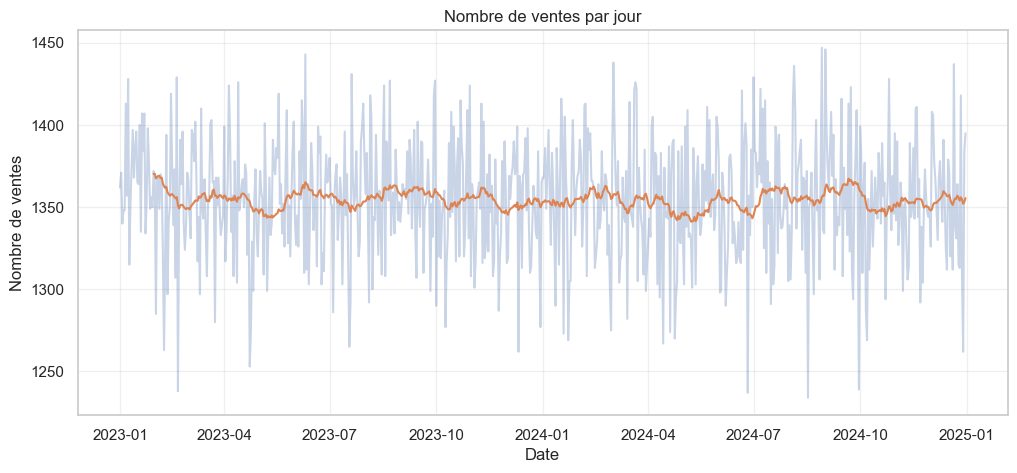

Interprétation :
- Le nombre de ventes varie d’un jour à l’autre, ce qui montre une activité commerciale fluctuante.
- Certaines périodes présentent un volume de transactions plus élevé.
- Cela permet d’identifier les jours ou périodes de forte activité.
- Cette analyse complète celle du chiffre d’affaires en apportant une vision du volume des ventes.


In [35]:
df["order_date"] = pd.to_datetime(df["order_date"])

sales_count_per_day = (
    df.groupby("order_date")
    .size()
    .reset_index(name="nb_ventes")
)

sales_count_per_day["trend"] = sales_count_per_day["nb_ventes"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=sales_count_per_day, x="order_date", y="nb_ventes", alpha=0.3)

sns.lineplot(data=sales_count_per_day, x="order_date", y="trend")

plt.title("Nombre de ventes par jour")
plt.xlabel("Date")
plt.ylabel("Nombre de ventes")
plt.grid(True, alpha=0.3)

plt.show()

sales_count_per_day.describe()

print("Interprétation :")
print("- Le nombre de ventes varie d’un jour à l’autre, ce qui montre une activité commerciale fluctuante.")
print("- Certaines périodes présentent un volume de transactions plus élevé.")
print("- Cela permet d’identifier les jours ou périodes de forte activité.")
print("- Cette analyse complète celle du chiffre d’affaires en apportant une vision du volume des ventes.")

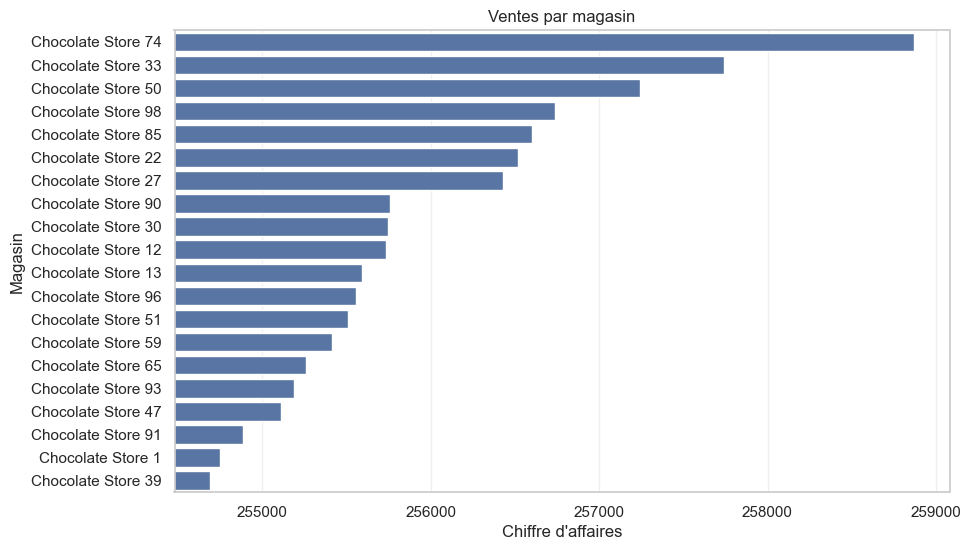

Interprétation :
- Les performances varient significativement selon les magasins.
- Certains génèrent beaucoup plus de chiffre d’affaires que d’autres.
- Cela peut s’expliquer par l’emplacement, la taille ou la clientèle.
- Identifier les magasins performants permet de reproduire leurs bonnes pratiques.


In [36]:
sales_by_store = (
    df.groupby("store_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=sales_by_store, x="revenue", y="store_name")

plt.title("Ventes par magasin")
plt.xlabel("Chiffre d'affaires")
plt.ylabel("Magasin")
plt.grid(True, axis="x", alpha=0.3)

xmin = sales_by_store["revenue"].min()
xmax = sales_by_store["revenue"].max()

marge = (xmax - xmin) * 0.05

plt.xlim(xmin - marge, xmax + marge)

plt.show()

sales_by_store.describe()

print("Interprétation :")
print("- Les performances varient significativement selon les magasins.")
print("- Certains génèrent beaucoup plus de chiffre d’affaires que d’autres.")
print("- Cela peut s’expliquer par l’emplacement, la taille ou la clientèle.")
print("- Identifier les magasins performants permet de reproduire leurs bonnes pratiques.")

# 13. Bilan de la séance

Nous avons appris à :

- utiliser **Seaborn** pour explorer des données
- comparer des groupes et visualiser des relations
- comprendre l'intérêt des **jointures**
- construire une table d'analyse à partir de plusieurs fichiers
- commencer à formuler des **interprétations** à partir de données

En d'autres termes, nous avons commencé à travailler comme le fait un analyste de données :

- observer
- assembler
- visualiser
- interpréter

## 14. Autres exemples de traitement des données possibles

Pour vous entraîner chez vous, vous pouvez trouver d'autres explorations des données possibles, par exemple ici : le chiffre d'affaires par mois

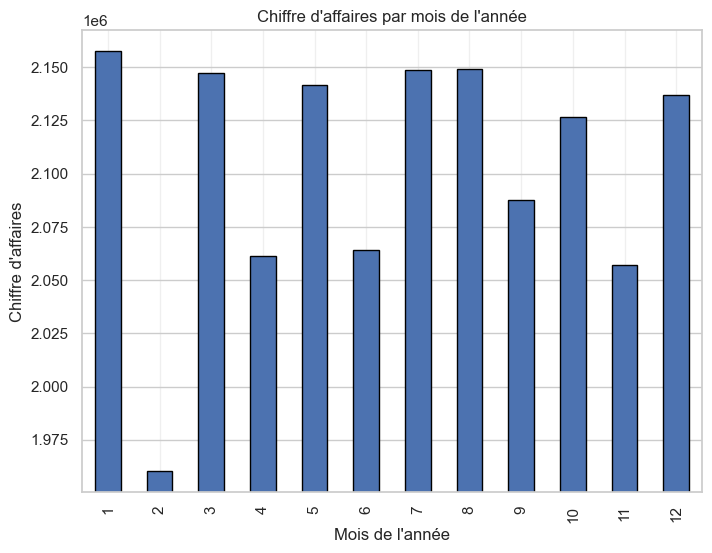

In [37]:
monthly_revenue = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(8, 6))

monthly_revenue.plot(kind="bar", edgecolor="black")

plt.title("Chiffre d'affaires par mois de l'année")
plt.xlabel("Mois de l'année")
plt.ylabel("Chiffre d'affaires")
plt.grid(True, axis="x", alpha=0.3)

ymin = monthly_revenue.min()
ymax = monthly_revenue.max()
marge = (ymax - ymin) * 0.05
plt.ylim(ymin - marge, ymax + marge)

plt.show()